# Calculate the Euler number as crosscheck for IPS sampler

in this notebook we only calculate the euler number using the FS metric. This can similarly be done for the boosted metrics, as shown in the last section of the notebook

In [ ]:
import os
import pickle

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "-1")

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import tensorflow as tf
import tensorflow.keras as tfk

from warped_metrics import (
    BoostedSpectralPhiModel,
    PointGeneratorMathematica,
    PointGeneratorMathematicaIPS,
    SigmaCallback,
    SigmaLoss,
    SpectralFSModelComp,
    VolkCallback,
    compute_riemann,
    compute_riemann_par_oomsafe,
    configure_tensorflow_runtime,
    get_chern_classes,
    integrate_standard,
    integrate_weighted,
    prepare_tf_basis,
    train_model,
)

configure_tensorflow_runtime(cpu_only=True)


# Generate dataset and calculate the Euler number

Let us compute some quantities in differential geometry following Berglund et al [2211.09801].

For a Kahler manifold, we have for the Christoffel Symbols

$\Gamma^{a}_{bc}=(\partial_b g_{c\bar{d}})g^{\bar{d} a} = (\Gamma^{\bar a}_{\bar b\bar c})^*$

Then the non-zero entries of the Riemann tensor are

$R^{a}_{b\bar{c}d}=-\bar\partial_{\bar c} \Gamma^{a}_{bd}$ and $R^{a}_{\bar{b}cd}=\bar\partial_{\bar b} \Gamma^{a}_{cd}$

(and the complex conjugates of the above)

The Ricci tensor is 

$\text{Ric}_{a\bar{b}}=R^c_{ca\bar{b}}=-\partial_a\bar\partial_{\bar{b}}\log\det g$

The Riemann tensor $R^{a}_{bm\bar{n}}$ is related to the curvature form $\mathcal{R}^a_b$ by

$\mathcal{R}^a_b=R^{a}_{bm\bar{n}}dz^m\wedge dz^n$

From this we obtain

$\text{tr}\mathcal{R}=R^a_{am\bar n} dz^m\wedge d\bar{z}^{\bar n} = -i \text{Ric}_{m\bar n} dz^m\wedge d\bar{z}^{\bar n}$

$\text{tr}\mathcal{R}^2=R^a_{bm_1\bar n_1}R^b_{am_2\bar n_2} dz^{m_1} \wedge d\bar z^{\bar n_1}\wedge dz^{m_2} \wedge d\bar z^{\bar n_2}$

$\text{tr}\mathcal{R}^3=R^a_{bm_1\bar n_1}R^b_{cm_2\bar n_2}R^c_{am_3\bar n_3} dz^{m_1} \wedge d\bar z^{\bar n_1}\wedge dz^{m_2} \wedge d\bar z^{\bar n_2}\wedge dz^{m_3} \wedge d\bar z^{\bar n_3}$

For the total Chern class, we have

$c(t)=\det(1+t\frac{i}{2\pi} J)=c_0+c_1 t+c_2 t^2 + c_3 t^3 + \ldots$

which gives

$c_0=1$

$c_1 = \frac{i}{2\pi}\text{tr}\mathcal{R}$

$c_2 = \frac{1}{2(2\pi)^2}(\text{tr}\mathcal{R}^2-(\text{tr}\mathcal{R})^2)$

$c_3 = \frac{1}{3}c_1\wedge c_2 + \frac{1}{3(2\pi)^2}c_1\wedge\text{tr}\mathcal{R}^2-\frac{i}{3(2\pi)^3}\text{tr}\mathcal{R}^3=-\frac{i}{3(2\pi)^3}\text{tr}\mathcal{R}^3$ where the last equation is true on the CY where $c_1=0$


# Standard sampling 

## Away from conifold

In [ ]:
psi = 0.497 + 0.1 * 1.j
monomials = np.array((5 * np.eye(5, dtype=np.int64)).tolist() + [[1,1,1,1,1]])
coefficients = np.array(np.ones(5).tolist() + [-5 * psi])
kmoduli = np.ones(1)
ambient = np.array([4])
n_fold = 3
num_pts = 100000
num_regions = 5
chi_mean_error = 0
error_squared = 0
chi_mean = 0
base_dir = "IPS"
pg = PointGeneratorMathematica([monomials], [coefficients], kmoduli, ambient)
for n_try in range(10):
    dirname = os.path.join(base_dir,'points_quintic_{:}_{:}_{:}'.format(psi, num_pts, n_try))
    if not os.path.exists(os.path.join(dirname, 'basis.pickle')):
        kappa = pg.prepare_dataset(num_pts, dirname)#, psi=psi)
        pg.prepare_basis(dirname, kappa)

    riemann_path = os.path.join(dirname, 'riemann.pickle')
    data = np.load(os.path.join(dirname, 'dataset.npz'))
    BASIS = np.load(os.path.join(dirname, 'basis.pickle'), allow_pickle=True)
    BASIS = prepare_tf_basis(BASIS)
    new_basis = {}
    for key in BASIS:
        new_basis[key] = tf.cast(BASIS[key], dtype=tf.complex64)
    BASIS = new_basis
    new_data = {}
    for key in data:
        new_data[key] = data[key]
    data = new_data
    kappa = BASIS['KAPPA']

    pts = np.concatenate([data['X_train'], data['X_val']], axis=0)
    wo = np.concatenate([data['y_train'], data['y_val']], axis=0)
    comp_model = SpectralFSModelComp(None, BASIS, alpha=[1.]*5, deg=2, monomials=monomials)
    
    riemann_tensor = compute_riemann(riemann_path, pts, comp_model, batch_size=10000)
    c1, c2, c3, c3_form = get_chern_classes(riemann_tensor, comp_model)
    chi = tf.math.real(integrate_standard(c3_form, pts, wo, comp_model, normalize_to_vol=5.))
    chi_mean += chi
    chi_mean_error += tf.abs(chi+200.)
    error_squared += tf.abs(chi+200.)**2
    print(f"chi = {chi:.2f}")

chi_mean *= 1./(n_try+1)
chi_mean_error *= 1./(1+n_try)
variance = (error_squared/(1+n_try))**0.5
print(f"chi_mean= {chi_mean:.2f}")
print(f"chi mean error= {chi_mean_error:.2f}")
print(f"variance= {variance:.2f}")

chi = -200.88
chi = -200.62
chi = -198.87
chi = -201.43
chi = -200.22
chi = -199.92
chi = -199.32
chi = -200.30
chi = -198.51
chi = -198.67
chi_mean= -199.87
chi mean error= 0.82
variance= 0.95


## Close to conifold 

In [ ]:
psi = 1.035 - 0.02 * 1.j
monomials = np.array((5 * np.eye(5, dtype=np.int64)).tolist() + [[1,1,1,1,1]])
coefficients = np.array(np.ones(5).tolist() + [-5 * psi])
kmoduli = np.ones(1)
ambient = np.array([4])
n_fold = 3
num_pts = 100000
num_regions = 5
chi_mean_error = 0
error_squared = 0
chi_mean = 0
base_dir = "IPS"
pg = PointGeneratorMathematica([monomials], [coefficients], kmoduli, ambient)
for n_try in range(10):
    dirname = os.path.join(base_dir,'points_quintic_{:}_{:}_{:}'.format(psi, num_pts, n_try))
    if not os.path.exists(os.path.join(dirname, 'basis.pickle')):
        kappa = pg.prepare_dataset(num_pts, dirname)#, psi=psi)
        pg.prepare_basis(dirname, kappa)

    riemann_path = os.path.join(dirname, 'riemann.pickle')
    data = np.load(os.path.join(dirname, 'dataset.npz'))
    BASIS = np.load(os.path.join(dirname, 'basis.pickle'), allow_pickle=True)
    BASIS = prepare_tf_basis(BASIS)
    new_basis = {}
    for key in BASIS:
        new_basis[key] = tf.cast(BASIS[key], dtype=tf.complex64)
    BASIS = new_basis
    new_data = {}
    for key in data:
        new_data[key] = data[key]
    data = new_data
    kappa = BASIS['KAPPA']

    pts = np.concatenate([data['X_train'], data['X_val']], axis=0)
    wo = np.concatenate([data['y_train'], data['y_val']], axis=0)
    comp_model = SpectralFSModelComp(None, BASIS, alpha=[1.]*5, deg=2, monomials=monomials)
    
    riemann_tensor = compute_riemann(riemann_path, pts, comp_model, batch_size=10000)
    c1, c2, c3, c3_form = get_chern_classes(riemann_tensor, comp_model)
    chi = tf.math.real(integrate_standard(c3_form, pts, wo, comp_model, normalize_to_vol=5.))
    chi_mean += chi
    chi_mean_error += tf.abs(chi+200.)
    error_squared += tf.abs(chi+200.)**2
    print(f"chi = {chi:.2f}")

chi_mean *= 1./(1+n_try)
chi_mean_error *= 1./(1+n_try)
variance = (error_squared/(1+n_try))**0.5
print(f"chi_mean= {chi_mean:.2f}")
print(f"chi mean error= {chi_mean_error:.2f}")
print(f"variance= {variance:.2f}")


chi = -259.03
chi = -243.69
chi = -220.81
chi = -251.91
chi = -211.15
chi = -165.12
chi = -263.32
chi = -247.22
chi = -228.04
chi = -191.16
chi_mean= -228.15
chi mean error= 36.89
variance= 41.19


# IPS Sampling

## Away from conifold

In [ ]:
psi = 1.035 - 0.02 * 1.j
monomials = np.array((5 * np.eye(5, dtype=np.int64)).tolist() + [[1,1,1,1,1]])
coefficients = np.array(np.ones(5).tolist() + [-5 * psi])
kmoduli = np.ones(1)
ambient = np.array([4])
n_fold = 3
num_pts = 100000
num_regions = 5
chi_mean = 0
chi_mean_error = 0
error_squared = 0
chi_m_new = 0
chi_m_nat = 0

base_dir = "IPS"
pg = PointGeneratorMathematicaIPS([monomials], [coefficients], kmoduli, ambient)
for n_try in range(10):
    dirname = os.path.join(base_dir,'points_quintic_ips_{:}_{:}_{:}'.format(psi, num_pts, n_try))
    if not os.path.exists(os.path.join(dirname, 'basis.pickle')):
        kappas = pg.prepare_dataset(num_pts, dirname, num_regions=num_regions, psi=psi)
        pg.prepare_basis(dirname, kappas)

    riemann_path = os.path.join(dirname, 'riemann.pickle')
    data = np.load(os.path.join(dirname, 'dataset.npz'))
    BASIS = np.load(os.path.join(dirname, 'basis.pickle'), allow_pickle=True)
    BASIS = prepare_tf_basis(BASIS)
    new_basis = {}
    for key in BASIS:
        new_basis[key] = tf.cast(BASIS[key], dtype=tf.complex64)
    BASIS = new_basis
    new_data = {}
    for key in data:
        new_data[key] = data[key]
    data = new_data
    kappa = BASIS['KAPPA']

    pts = np.concatenate([data['X_train'], data['X_val']], axis=0)
    wo = np.concatenate([data['y_train'], data['y_val']], axis=0)
    comp_model = SpectralFSModelComp(None, BASIS, alpha=[1.]*5, deg=2, monomials=monomials)
    
    riemann_tensor = compute_riemann(riemann_path, pts, comp_model, batch_size=10000)
    c1, c2, c3, c3_form = get_chern_classes(riemann_tensor, comp_model)
    chi = tf.math.real(integrate_standard(c3_form, pts, wo, comp_model, normalize_to_vol=5.))
    chi_mean += chi
    chi_mean_error += tf.abs(chi+200.)
    error_squared += tf.abs(chi+200.)**2
    print(f"chi = {chi:.2f}")

chi_mean *= 1. / (1 + n_try)
chi_mean_error *= 1. / (1 + n_try)
variance = (error_squared / (1 + n_try))**0.5
print(f"chi_mean= {chi_mean:.2f}")
print(f"chi mean error= {chi_mean_error:.2f}")
print(f"variance= {variance:.2f}")


chi naive = -203.27
chi new = -203.22
chi naive = -200.96
chi new = -200.79
chi naive = -198.93
chi new = -198.80
chi naive = -200.69
chi new = -200.68
chi naive = -199.99
chi new = -199.98
chi naive = -202.15
chi new = -201.92
chi naive = -200.72
chi new = -200.63
chi naive = -201.22
chi new = -201.10
chi naive = -199.67
chi new = -199.68
chi naive = -200.61
chi new = -200.58
chi mean new=-200.74
chi mean naive=-200.82


## Close to conifold

In [ ]:
psi = 1.035 - 0.02 * 1.j
monomials = np.array((5 * np.eye(5, dtype=np.int64)).tolist() + [[1,1,1,1,1]])
coefficients = np.array(np.ones(5).tolist() + [-5 * psi])
kmoduli = np.ones(1)
ambient = np.array([4])
n_fold = 3
num_pts = 100000
num_regions = 5
chi_mean = 0
chi_mean_error = 0
error_squared = 0
chi_m_new = 0
chi_m_nat = 0

base_dir = "IPS"
pg = PointGeneratorMathematicaIPS([monomials], [coefficients], kmoduli, ambient)
for n_try in range(10):
    dirname = os.path.join(base_dir,'points_quintic_ips_{:}_{:}_{:}'.format(psi, num_pts, n_try))
    if not os.path.exists(os.path.join(dirname, 'basis.pickle')):
        kappas = pg.prepare_dataset(num_pts, dirname, num_regions=num_regions, psi=psi)
        pg.prepare_basis(dirname, kappas)

    riemann_path = os.path.join(dirname, 'riemann.pickle')
    data = np.load(os.path.join(dirname, 'dataset.npz'))
    BASIS = np.load(os.path.join(dirname, 'basis.pickle'), allow_pickle=True)
    BASIS = prepare_tf_basis(BASIS)
    new_basis = {}
    for key in BASIS:
        new_basis[key] = tf.cast(BASIS[key], dtype=tf.complex64)
    BASIS = new_basis
    new_data = {}
    for key in data:
        new_data[key] = data[key]
    data = new_data
    kappas = BASIS['KAPPA']

    pts = np.concatenate([data['X_train'], data['X_val']], axis=0)
    wo = np.concatenate([data['y_train'], data['y_val']], axis=0)
    comp_model = SpectralFSModelComp(None, BASIS, alpha=[1.]*5, deg=2, monomials=monomials)
    
    riemann_tensor = compute_riemann(riemann_path, pts, comp_model, batch_size=10000)
    c1, c2, c3, c3_form = get_chern_classes(riemann_tensor, comp_model)
    chi_naive = tf.math.real(integrate_standard(c3_form, pts, wo, comp_model, normalize_to_vol=5.))
    chi_new = tf.math.real(integrate_weighted(c3_form, pts, wo, comp_model, kappas, normalize_to_vol=5.))
    print(f"chi naive = {chi_naive:.2f}")
    print(f"chi new = {chi_new:.2f}")
    chi_m_new +=chi_new
    chi_m_nat += chi_naive
    
chi_m_new *=1./(1+n_try)
chi_m_nat *= 1./(1+n_try)
print(f"chi mean new={chi_m_new:.2f}")
print(f"chi mean naive={chi_m_nat:.2f}")

chi naive = -227.88
chi new = -235.36
chi naive = -225.51
chi new = -229.81
chi naive = 96.87
chi new = 111.94
chi naive = -191.84
chi new = -196.29
chi naive = -200.38
chi new = -205.24
chi naive = -189.18
chi new = -195.99
chi naive = -247.21
chi new = -249.32
chi naive = -209.23
chi new = -214.18
chi naive = -229.64
chi new = -233.87
chi naive = -218.39
chi new = -224.75
chi mean new=-187.29
chi mean naive=-184.24


# Calculate Euler number from two-step metric

In [ ]:
psi = 0.497 + 0.1 * 1.j
monomials = np.array((5 * np.eye(5, dtype=np.int64)).tolist() + [[1,1,1,1,1]])
coefficients = np.array(np.ones(5).tolist() + [-5 * psi])
kmoduli = np.ones(1)
ambient = np.array([4])
n_fold = 3
num_pts = 100000
num_regions = 5
chi_mean = 0
chi_mean_error = 0
error_squared = 0
chi_m_new = 0
chi_m_nat = 0

base_dir = "IPS"
pg = PointGeneratorMathematicaIPS([monomials], [coefficients], kmoduli, ambient)
for n_try in range(10):
    dirname = os.path.join(base_dir,'points_quintic_ips_{:}_{:}_{:}'.format(psi, num_pts, n_try))
    if not os.path.exists(os.path.join(dirname, 'basis.pickle')):
        kappas = pg.prepare_dataset(num_pts, dirname, num_regions=num_regions, psi=psi)
        pg.prepare_basis(dirname, kappas)

    riemann_path = os.path.join(dirname, 'riemann.pickle')
    data = np.load(os.path.join(dirname, 'dataset.npz'))
    BASIS = np.load(os.path.join(dirname, 'basis.pickle'), allow_pickle=True)
    BASIS = prepare_tf_basis(BASIS)
    new_basis = {}
    for key in BASIS:
        new_basis[key] = tf.cast(BASIS[key], dtype=tf.complex64)
    BASIS = new_basis
    new_data = {}
    for key in data:
        new_data[key] = data[key]
    data = new_data
    kappa = BASIS['KAPPA']

    pts = np.concatenate([data['X_train'], data['X_val']], axis=0)
    wo = np.concatenate([data['y_train'], data['y_val']], axis=0)
    comp_model = SpectralFSModelComp(None, BASIS, alpha=[1.]*5, deg=2, monomials=monomials)
    
    riemann_tensor = compute_riemann(riemann_path, pts, comp_model, batch_size=10000)
    c1, c2, c3, c3_form = get_chern_classes(riemann_tensor, comp_model)
    chi = tf.math.real(integrate_standard(c3_form, pts, wo, comp_model, normalize_to_vol=5.))
    chi_mean += chi
    chi_mean_error += tf.abs(chi+200.)
    error_squared += tf.abs(chi+200.)**2
    print(f"chi = {chi:.2f}")

chi_mean *= 1. / (1 + n_try)
chi_mean_error *= 1. / (1 + n_try)
variance = (error_squared / (1 + n_try))**0.5
print(f"chi_mean= {chi_mean:.2f}")
print(f"chi mean error= {chi_mean_error:.2f}")
print(f"variance= {variance:.2f}")


load some data set and the tweo-step metric. Then calculate the Riemann based on the different metrics. This works for IPS as well as standard Sampling. First load some data for learning the metric

absl:WARNING:At this time, the v2.11+ optimizer `tf.keras.optimizers.Adam` runs slowly on M1/M2 Macs, please use the legacy Keras optimizer instead, located at `tf.keras.optimizers.legacy.Adam`.


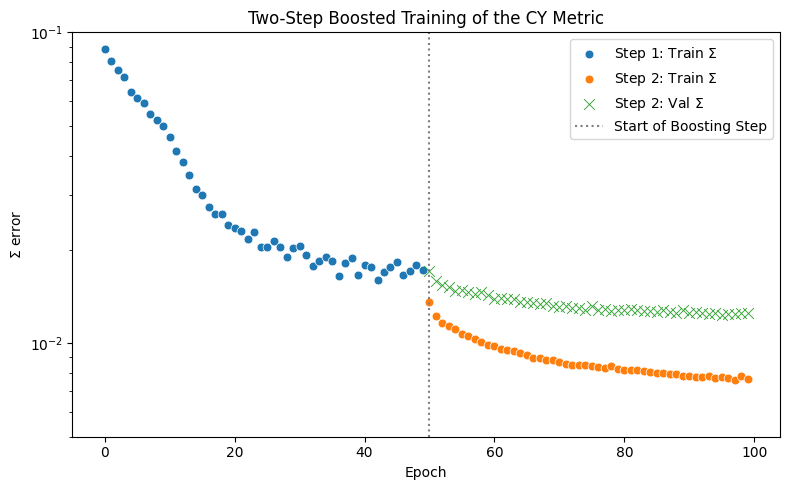

In [33]:
psi = 1.035 - 0.02 * 1.j
monomials = np.array((5 * np.eye(5, dtype=np.int64)).tolist() + [[1,1,1,1,1]])
coefficients = np.array(np.ones(5).tolist() + [-5 * psi])
kmoduli = np.ones(1)
ambient = np.array([4])
n_fold = 3
num_pts = 100000
num_regions = 5
chis = []
n_try = 0

pg = PointGeneratorMathematica([monomials], [coefficients], kmoduli, ambient)#, kernel_path='/Applications/Wolfram.app/Contents/MacOS/MathKernel')

dirname = os.path.join(base_dir,'points_quintic_{:}_{:}_{:}'.format(psi, num_pts, n_try))
if not os.path.exists(os.path.join(dirname, 'basis.pickle')):
    kappas = pg.prepare_dataset(num_pts, dirname)
    pg.prepare_basis(dirname, kappas)

data = np.load(os.path.join(dirname, 'dataset.npz'))
BASIS = np.load(os.path.join(dirname, 'basis.pickle'), allow_pickle=True)
BASIS = prepare_tf_basis(BASIS)
new_basis = {}
for key in BASIS:
    new_basis[key] = tf.cast(BASIS[key], dtype=tf.complex64)
BASIS = new_basis

# train first NN 

deg = 2
layers = 2
nlayer = 3
nHidden = 64
n_in = 2 * (BoostedSpectralPhiModel.get_num_sections(n_fold + 2, deg))**2
n_out = 1
act = "gelu"
nEpochs = 50
bSizes = [64, 20000]
alpha = [1., 1., 1., 1., 1.]

# ---- cheaper callback validation subset ----
Xv, yv = data["X_val"], data["y_val"]
val_cb_n = min(len(Xv), 5000)
cb_data = (Xv[:val_cb_n], yv[:val_cb_n])

scb = SigmaCallback(cb_data)
volkcb = VolkCallback(cb_data)
cb_list = [scb, volkcb]

test_metrics = [SigmaLoss()]

# ---- build model ----
nn_phi_1 = tf.keras.Sequential()
nn_phi_1.add(tfk.Input(shape=(n_in,)))
for _ in range(nlayer):
    nn_phi_1.add(tfk.layers.Dense(nHidden, activation=act))
# dtype float32 to be safe with mixed precision
nn_phi_1.add(tfk.layers.Dense(n_out, use_bias=False, dtype="float32"))

model_path = os.path.join(dirname, "nn_phi_1.keras")
hist_path  = os.path.join(dirname, "training_history_1.pickle")

phimodel = BoostedSpectralPhiModel([nn_phi_1], BASIS, alpha=alpha, deg=[deg], monomials=monomials)

# optimizer (simple + fast)
opt_phi = tfk.optimizers.Adam(learning_rate=1e-3)

if not os.path.exists(model_path):
    # optional: reduce verbosity for speed
    phimodel, training_history = train_model(
        phimodel,
        data,
        optimizer=opt_phi,
        epochs=nEpochs,
        batch_sizes=bSizes,
        verbose=1,
        custom_metrics=test_metrics,
        callbacks=cb_list,
    )
    nn_phi_1 = phimodel.models[-1]
    nn_phi_1.save(model_path)
    with open(hist_path, "wb") as f:
        pickle.dump(training_history, f)

nn_phi_1 = tf.keras.models.load_model(model_path, compile=False)
nn_phi_1.trainable = True
_ = nn_phi_1(tf.zeros((1, n_in), dtype=tf.float32))

with open(hist_path, "rb") as f:
    training_history_1 = pickle.load(f)


#now train next NN with starting point given by the trained first NN 

# need smaller batch sizes with two NN to not crash the kernel.
bSizes = [64, 20000]

def build_phi_network(n_in, nlayer, nHidden, act, n_out=1, mixed_precision_safe=True):
    m = tf.keras.Sequential()
    m.add(tfk.Input(shape=(n_in,)))
    for _ in range(nlayer):
        m.add(tfk.layers.Dense(nHidden, activation=act))
    # last layer float32 if mixed precision is enabled; harmless otherwise
    if mixed_precision_safe:
        m.add(tfk.layers.Dense(n_out, use_bias=False, dtype="float32"))
    else:
        m.add(tfk.layers.Dense(n_out, use_bias=False))
    return m

phi2_path  = os.path.join(dirname, "nn_phi_2.keras")
hist2_path = os.path.join(dirname, "training_history_2.pickle")

if os.path.exists(phi2_path):
    nn_phi_2 = tf.keras.models.load_model(phi2_path, compile=False)
else:
    nn_phi_2 = build_phi_network(n_in, nlayer, nHidden, act, n_out=n_out, mixed_precision_safe=True)

    _ = nn_phi_1(tf.zeros((1, n_in), dtype=tf.float32))
    _ = nn_phi_2(tf.zeros((1, n_in), dtype=tf.float32))
    nn_phi_2.set_weights(nn_phi_1.get_weights())

    phimodel_2_tmp = BoostedSpectralPhiModel([nn_phi_1, nn_phi_2], BASIS, alpha=alpha, deg=[deg], monomials=monomials)

    opt_phi = tfk.optimizers.Adam(learning_rate=1e-3)
    phimodel_2_tmp, training_history_2 = train_model(
        phimodel_2_tmp, data,
        optimizer=opt_phi,
        epochs=nEpochs,
        batch_sizes=bSizes,
        verbose=1,
        custom_metrics=test_metrics,
        callbacks=cb_list,
    )

    nn_phi_2 = phimodel_2_tmp.models[-1]
    nn_phi_2.save(phi2_path)
    with open(hist2_path, "wb") as f:
        pickle.dump(training_history_2, f)

# ensure built
nn_phi_2.trainable = True
_ = nn_phi_2(tf.zeros((1, n_in), dtype=tf.float32))

# always create phimodel_2 (whether loaded or trained)
phimodel_2 = BoostedSpectralPhiModel([nn_phi_1, nn_phi_2], BASIS, alpha=alpha, deg=[deg], monomials=monomials)

# history
training_history_2 = None
if os.path.exists(hist2_path):
    with open(hist2_path, "rb") as f:
        training_history_2 = pickle.load(f)

sigma_loss_1 = np.array(training_history_1['sigma_loss'])
sigma_loss_2 = np.array(training_history_2['sigma_loss'])
sigma_val_2  = np.array(training_history_2['sigma_val'])

# Epoch indexing
epochs_1 = np.arange(len(sigma_loss_1))
epochs_2 = np.arange(len(sigma_loss_1),
                     len(sigma_loss_1) + len(sigma_loss_2))

plt.figure(figsize=(8,5))

# Step 1 training
sns.scatterplot(
    x=epochs_1,
    y=sigma_loss_1,
    label="Step 1: Train $\Sigma$",
    s=40
)

# Step 2 training
sns.scatterplot(
    x=epochs_2,
    y=sigma_loss_2,
    label="Step 2: Train $\Sigma$",
    s=40
)

# Step 2 validation
sns.scatterplot(
    x=epochs_2,
    y=sigma_val_2,
    marker="x",
    label="Step 2: Val $\Sigma$",
    s=60
)

# Vertical transition line (now in legend)
plt.axvline(
    len(sigma_loss_1),
    color='gray',
    linestyle=':',
    linewidth=1.5,
    label="Start of Boosting Step"
)
plt.ylim(5e-3, 1e-1)   # adjust 1e-6 if needed
plt.yscale('log')
plt.xlabel("Epoch")
plt.ylabel(r"$\Sigma$ error")
plt.title("Two-Step Boosted Training of the CY Metric")

plt.legend()
plt.tight_layout()


plt.show()

In [ ]:
pts = np.concatenate([data["X_train"], data["X_val"]], axis=0)
wo  = np.concatenate([data["y_train"], data["y_val"]], axis=0)

phimodel_FS = BoostedSpectralPhiModel([], BASIS, alpha=alpha, deg=[deg], monomials=monomials)
riem_FS = compute_riemann_par_oomsafe(os.path.join(dirname, "riemann_FS.pickle"), pts, phimodel_FS, batch_size=10000)
c1_FS, c2_FS, c3_FS, c3_form_FS = get_chern_classes(riem_FS, phimodel_FS)
chi_FS = tf.math.real(integrate_standard(c3_form_FS, pts, wo, phimodel_FS, normalize_to_vol=5.0))
print(chi_FS)


riem_1 = compute_riemann_par_oomsafe(os.path.join(dirname, "riemann_1.pickle"), pts, phimodel, batch_size=250)  # try bigger than 100
c1_1, c2_1, c3_1, c3_form_1 = get_chern_classes(riem_1, phimodel)
chi_1 = tf.math.real(integrate_standard(c3_form_1, pts, wo, phimodel, normalize_to_vol=5.0))
print(chi_1)

riem_2 = compute_riemann_par_oomsafe(os.path.join(dirname, "riemann_2.pickle"), pts, phimodel_2, batch_size=125) 
c1_2, c2_2, c3_2, c3_form_2 = get_chern_classes(riem_2, phimodel_2)
chi_2 = tf.math.real(integrate_standard(c3_form_2, pts, wo, phimodel_2, normalize_to_vol=5.0))
print(chi_2)